<a href="https://colab.research.google.com/github/NeonVP31/Statprak/blob/main/dz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Serial test

Идея: разбить последовательность x1,x2,x3,...,x2n на последовательные ряды длиной 2: (x1,x2),(x3,x4),...,(x2n−1,x2n) и рассматривать каждый элемент как случайную и независимую точку в двумерном пространстве. Затем применяем хи-квадрат. Аналогичным образом можно построить ряды длиной 3,4 и т.д.

### Problem 1
Внедрить последовательный тест и применить его к `образцам`

In [ ]:
# Your code here
import random
import math
from collections import Counter

def serial_test(samples, bins=10):
    """
    samples - list of floats in [0,1)
    bins - number of  intervals on axis (total cells = bins^2)

    chi2_stat - chi-square statistic

    """
    n = len(samples)
    if n < 2:
        print("Need at least two samples for serial test")
        return -1


    indices = [int(x * bins) for x in samples]

    pair_counts = Counter()
    for i in range(n - 1):
        pair = (indices[i], indices[i+1])
        pair_counts[pair] += 1


    expected = (n - 1) / (bins * bins)


    chi2_stat = 0.0
    for count in pair_counts.values():
        chi2_stat += (count - expected) ** 2 / expected


    df = bins * bins - 1


    from scipy.stats import chi2
    p = 1 - chi2.cdf(chi2_stat, df)

    return chi2_stat, p, df


def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m


rng.current = 1

samples = [rng() for _ in range(1000)]
chi2_stat, p_value, dof = serial_test(samples, bins=10)

print(f"Serial test results (bins=10):")
print(f"Chi-square statistic = {chi2_stat:.3f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p_value:.4f}")

if p_value < 0.05:
    print("definitely not a random sequence.")
else:
    print("may be a random sequence.")


Serial test results (bins=10):
Chi-square statistic = 95.194
Degrees of freedom = 99
P-value = 0.5896
may be a random sequence.


### Permutation test

Мы снова разбиваем последовательность $x_1, x_2, x_3, ..., x_{dn}$ на последовательные ряды длиной $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. Последовательность из $d$ элементов может быть упорядочена $d!$ способами, и каждый способ упорядочения равновероятен. Следовательно, идея теста состоит в том, чтобы подсчитать, сколько раз каждый порядок встречается в $n$ сериях, и применить тест $\ chi ^ 2$.

### Problem 2*

Реализуйте тест на перестановку и примените его к `образцам`

In [ ]:
# Your code here


Выбор параметров $m$, $a$ и $c$ оказывает существенное влияние на качество последовательности. Если параметры выбраны неудачно, это может привести к неожиданным последствиям:




In [ ]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
print("This sequence looks as random:")
random[:10]

This sequence looks as random:


[3.051897510886192e-05,
 0.00018310965970158577,
 0.0008239871822297573,
 0.003295936156064272,
 0.012359732296317816,
 0.04449496837332845,
 0.15573221957311034,
 0.533938602078706,
 0.8020416363142431,
 0.006802399177104235]

Гистограмма распределения похожа на равномерное распределение:

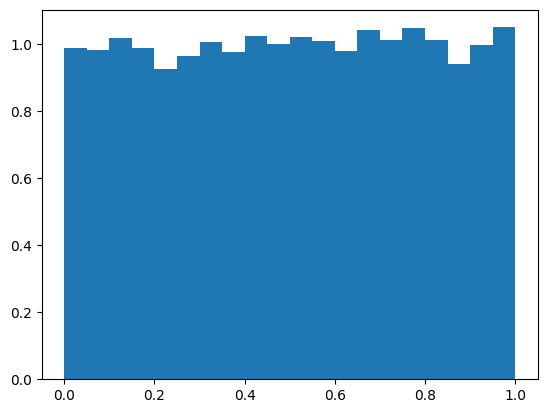

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure()

plt.hist(random, 20, density=True)
plt.show()

Однако последовательный тест показывает, что точки расположены на гиперплоскостях, что плохо согласуется с понятием случайности:

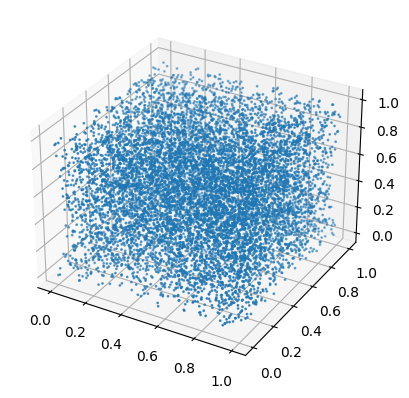

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(random[::3], random[1::3], random[2::3], s=1)
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(x=random[::3], y=random[1::3], z=random[2::3], opacity=0.1)
fig.update_traces(marker_size = 2)
fig.show()

### Problem 3
Проведите статистический тест, чтобы показать, что у rng_bad есть проблемы, а у rng_good - нет.

In [ ]:
import random
from collections import Counter
import numpy as np
from scipy.stats import chi2

# 3d because 2d didnt show not randomness
def serial_test_3d(samples, bins=10):

    n = len(samples)
    if n < 3:
        print("Need at least three samples for 3D serial test")
        return -1


    indices = [int(x * bins) for x in samples]


    triple_counts = Counter()
    for i in range(n - 2):
        triple = (indices[i], indices[i+1], indices[i+2])
        triple_counts[triple] += 1


    expected = (n - 2) / (bins ** 3)


    chi2_stat = 0.0
    for count in triple_counts.values():
        chi2_stat += (count - expected) ** 2 / expected


    df = bins ** 3 - 1

    p_value = 1 - chi2.cdf(chi2_stat, df)

    return chi2_stat, p_value, df



def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]

# def rng_good():
# didnt find in notebook :(

samples_bad = [rng_bad() for _ in range(30000)]
chi2, p, df = serial_test_3d(samples_bad, bins=10)
print("Bad generator 3D serial test (bins=10):")
print(f"Chi2 = {chi2:.3f}, df = {df}, p-value = {p:.4g}")
if p < 0.05:
    print("definitely not a random generation.\n")
else:
    print("may be random generation.")
# Test the good generator
# samples_good = [rng_good() for _ in range(30000)]
# chi2, p, df = serial_test_3d(samples_good, bins=10)
# print("Good generator  3D serial test (bins=10):")
# print(f"Chi2 = {chi2:.3f}, df = {df}, p-value = {p:.4g}")


Bad generator 3D serial test (bins=10):
Chi2 = 1153.543, df = 999, p-value = 0.0004691
definitely not a random generation.



### Problem 4
Смоделируйте выборку из 1000 человек из дискретного распределения по набору цифр 0,1,2,...,9 с весами 0.12,0.3,0.167,0.24,0.31,0.54,0.111,0.02,0.001,0.2 . Постройте гистограмму на основе выборки. Оптимизируйте алгоритм, упорядочив веса.

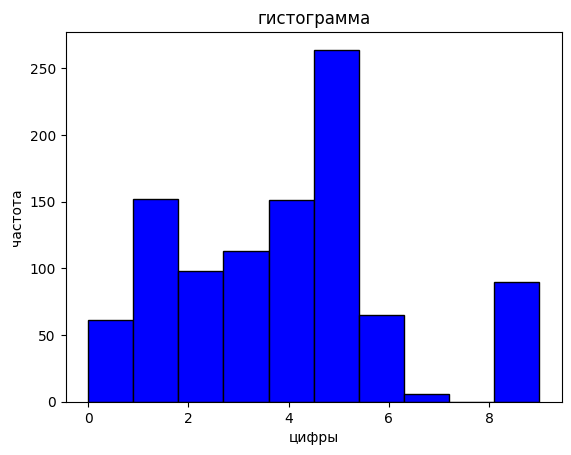

In [ ]:
# Your code here
import matplotlib.pyplot as plt
import numpy as np
values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
probabilities = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
probabilities /= sum(probabilities) # weight were not normed
sample = np.random.choice(values, size=1000, p=probabilities)
plt.hist(sample, bins=10, color='blue', edgecolor='black')
plt.title("гистограмма")
plt.xlabel('цифры')
plt.ylabel('частота')
plt.show()

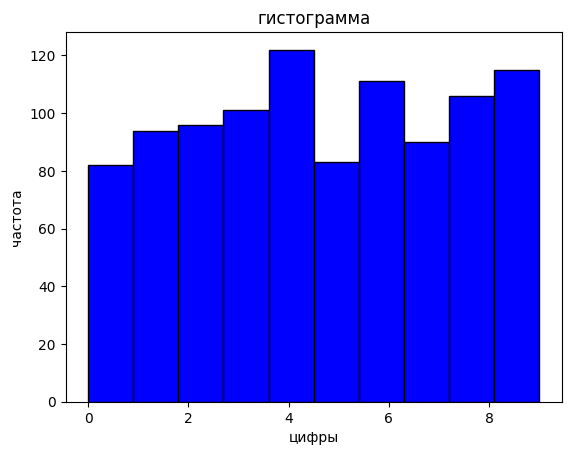

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
sample = np.random.choice(values, size=1000) # weights are equal
plt.hist(sample, bins=10, color='blue', edgecolor='black')
plt.title("гистограмма")
plt.xlabel('цифры')
plt.ylabel('частота')
plt.show()

# Generating a sample from a given distribution


Предположим, у нас есть генератор случайных чисел из сегмента [0, 1] (для этого используйте функцию np.random.rand()). Как получить выборку из другого распределения F?

## Inverse transform method

Идея метода обратного преобразования заключается в следующем предложении:

Если Θ имеет равномерное распределение в [0,1] , то F−1(Θ) распределяется в соответствии с законом F . (Для какого F это верно?)

### Problem 5
Смоделируйте выборку размером 1000 из распределения Exp(λ), используя метод обратного преобразования. Постройте гистограмму выборки и точный график плотности распределения.

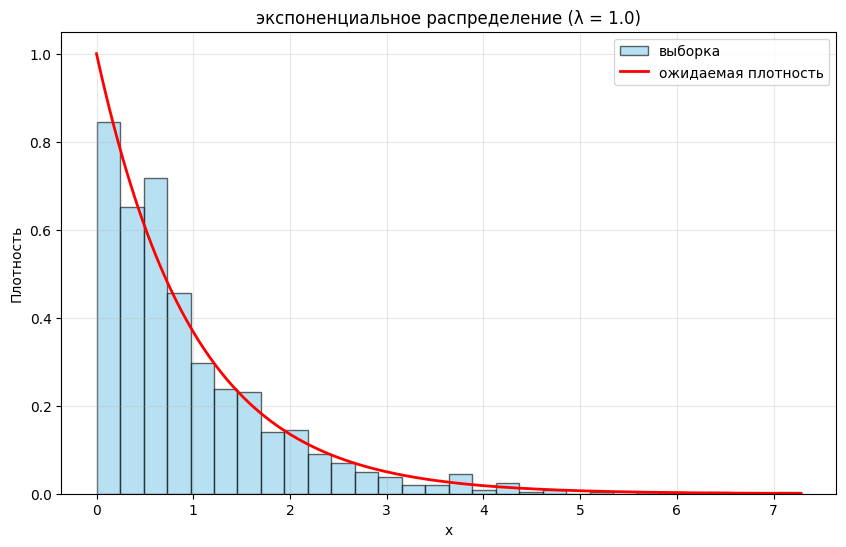

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

lambda_param = 1.0

n = 1000

u = np.random.rand(n) # uniform sample


x = -np.log(1 - u) / plambda


plt.figure(figsize=(10, 6))
plt.hist(x, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='выборка')

# Exp(lambda) distribution
x_plot = np.linspace(0, np.max(x), 500)
pdf = lambda_param * np.exp(-lambda_param * x_plot)
plt.plot(x_plot, pdf, 'r-', linewidth=2, label='ожидаемая плотность')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'экспоненциальное распределение (λ = {plambda})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Rejection sampling (Accept-reject method)

Идея метода заключается в выборке из распределения, из которого мы знаем, как делать выборку, а затем в выборе точек, которые соответствуют желаемому распределению. Более точно: допустим, мы знаем, как делать выборку из распределения с плотностью p, и мы хотим сделать выборку из распределения с плотностью π . Возьмем случайный x из распределения p . Затем возьмем y, равномерно распределенный на интервале [0,p(x)]. Если точка (x,y) попадает под график π, мы берем x в качестве элемента выборки из π. Если нет, мы повторяем процедуру для нового x. Рисунок иллюстрирует идею метода (плотности нормализованы таким образом, что одна полностью лежит под другой).:

Отбор проб с отбраковкой (метод "Принять-отклонить")

<img src=https://colcarroll.github.io/hamiltonian_monte_carlo_talk/images/bayes_talk.015.png style="width: 50%;"/>


Задача 6
Обоснуйте (устно), что метод "принять-отклонить" действительно использует выборки из требуемого распределения. Смоделируйте 1000 точек из распределения с плотностью
excos2x⋅I[−π2,π2]
. Постройте гистограмму выборки на выборке и сравните ее с графиком точной функции плотности.

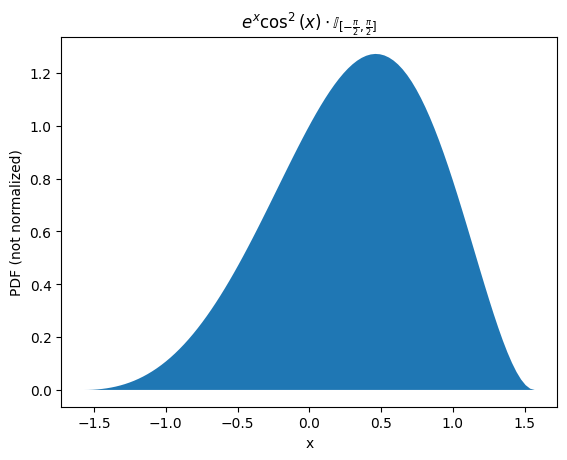

In [ ]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\c'
<>:58: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_6204/672313850.py:58: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Метод приёма-отклонения для $e^x \cos^2(x)$ ')


Доля принятых точек: 45.45%


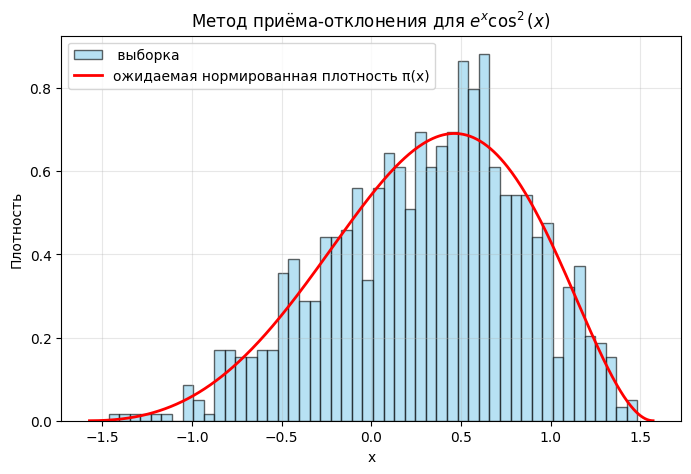

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def f(x):
    return np.exp(x) * np.cos(x) ** 2

a, b = -np.pi / 2, np.pi / 2

# нормируем
Z, _ = quad(f, a, b)
def pi(x):
    return f(x) / Z


def p(x):
    return 1 / (b - a)   # константа

# Находим максимум π(x)
x_vals = np.linspace(a, b, 1000)
pi_vals = pi(x_vals)
max_pi = np.max(pi_vals)

# Константа M, такая что π(x) <= M * p(x) для всех x
M = max_pi * (b - a)

#    Берём x из распределения p.
#    Генерируем y равномерно на [0, M * p(x)].
#    Принимаем x, если y ≤ π(x).
# ---------------------------
n_samples = 1000
samples = []
trials = 0

while len(samples) < n_samples:
    x = np.random.uniform(a, b)               # x из равномерного распределения
    y = np.random.uniform(0, max_pi)          # y из [0, max_pi]
    if y <= pi(x):
        samples.append(x)
    trials += 1

samples = np.array(samples)
accept_rate = n_samples / trials
print(f"Доля принятых точек: {accept_rate:.2%}")


# строим гистограмму
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=50, density=True, alpha=0.6,
         color='skyblue', edgecolor='black', label=' выборка')

x_plot = np.linspace(a, b, 500)
plt.plot(x_plot, pi(x_plot), 'r-', linewidth=2, label='ожидаемая нормированная плотность π(x)')

plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Метод приёма-отклонения для $e^x \cos^2(x)$ ')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Метод преобразования координат
Метод "принять-отклонить" в некоторых случаях может быть неэффективным и требовать слишком большого количества точек выборки. Альтернативой является попытка найти преобразование координат, которое преобразует простую область (из которой легко сделать выборку, например, единичный квадрат) в требуемую область, но сохраняет соотношение площадей (почему?).

### Problem 7
Смоделируйте и изобразите выборку из 500 точек, равномерно распределенных внутри данного треугольника, без использования метода отбора.

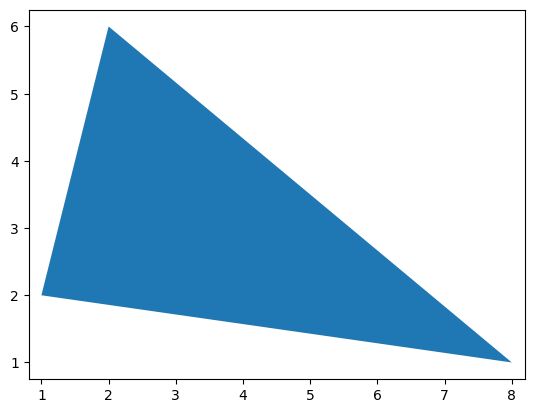

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

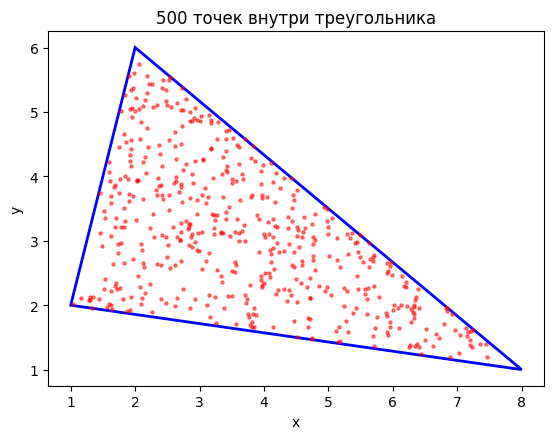

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n = 500

# равномерно генерируем два числа u, v в [0,1]
u = np.random.rand(n)
v = np.random.rand(n)

# Преобразование для попадания в треугольник (условие u + v ≤ 1)
mask = u + v > 1
u[mask] = 1 - u[mask]
v[mask] = 1 - v[mask]

# Вычисляем координаты точек с помощью барицентрических координат
# Точка = (1 - u - v) * A + u * B + v * C
points = (1 - u - v)[:, np.newaxis] * A + u[:, np.newaxis] * B + v[:, np.newaxis] * C

# Построение графика
fig, ax = plt.subplots()
polygon = Polygon([A, B, C], closed=True, edgecolor='blue', facecolor='none', linewidth=2)
ax.add_patch(polygon)
ax.scatter(points[:, 0], points[:, 1], s=5, color='red', alpha=0.5)
ax.set_aspect('equal')
ax.set_title('500 точек внутри треугольника')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

### Problem 8
Смоделируйте без использования метода выборки выборку из 500 точек, равномерно распределенных внутри единичной окружности. Изобразите полученные точки. Действительно ли они равномерно заполняют окружность?

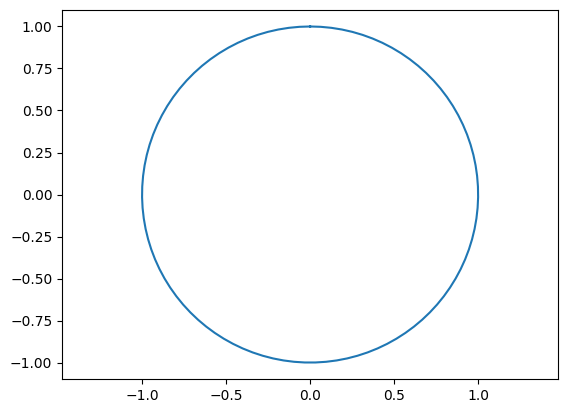

In [ ]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

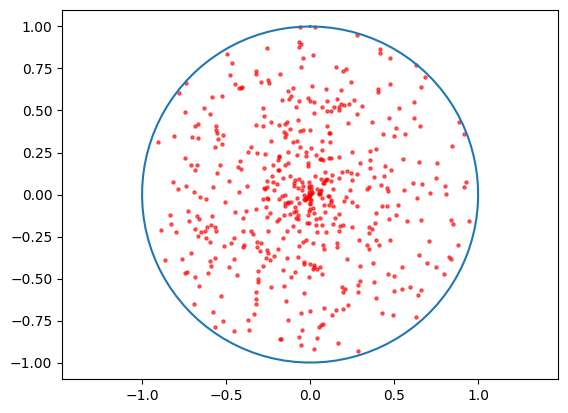

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


n = 500
r = np.random.rand(n)
phi = 2 * np.pi * np.random.rand(n)
x = r * np.cos(phi)
y = r * np.sin(phi)


fig = plt.figure()
plt.scatter(x, y, s=5, color='red', alpha=0.6, label='Точки')
t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()


# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

Докажите (устно), что следующий алгоритм (алгоритм Бокса-Мюллера, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) генерирует выборку независимых N(0,1) случайных величин. Измените метод, чтобы исключить вызовы тригонометрических функций np.sin и np.cos. Используя модифицированный метод, смоделируйте выборку размером 1000 из двумерного гауссова распределения со средним значением μ и ковариационной матрицей Σ, где
μ=(47)T,Σ=(20-4-440).
Постройте двумерную гистограмму результирующего распределения. Сравните среднее значение выборки и ковариационную матрицу с точными значениями.

In [ ]:
import seaborn as sns

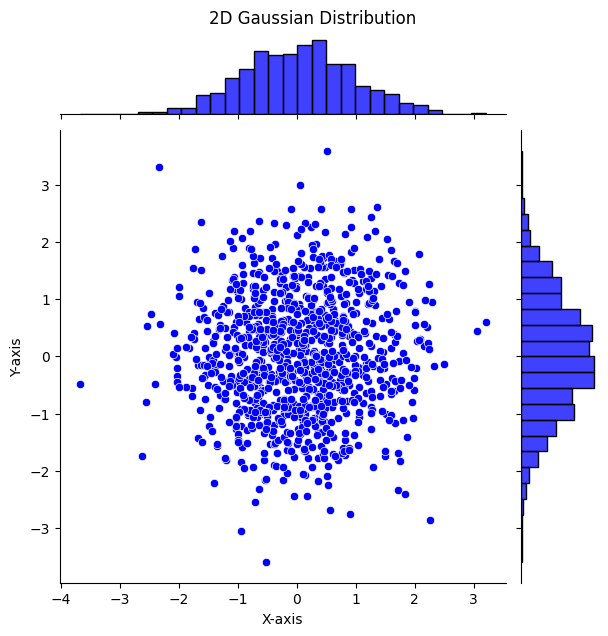

In [ ]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

ожидаемое среднее:
 [4 7]
Выборочное среднее:
 [3.96579029 7.0738991 ]

ожидаемое ковариационная матрица:
 [[20 -4]
 [-4 40]]
Выборочная ковариационная матрица:
 [[19.78922854 -4.28348861]
 [-4.28348861 40.60092173]]


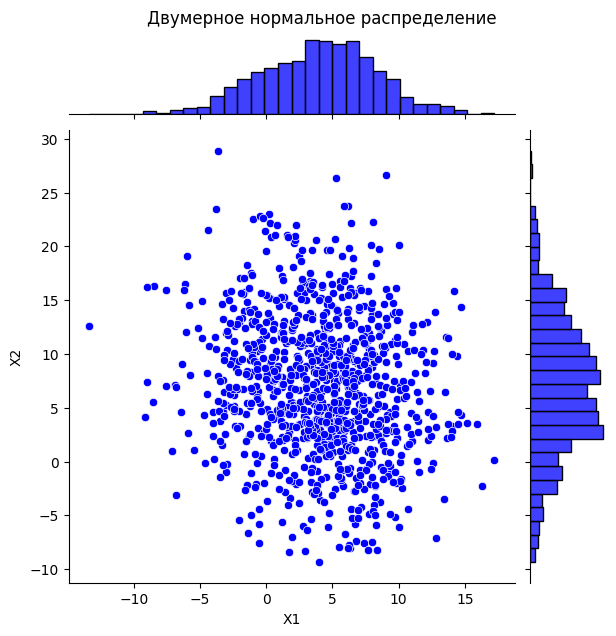

In [ ]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import cholesky

# ожидаемые параметры
mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])


def generate_standard_normal_polar(n):

    # Генерируем n пар (z1, z2) ~ N(0,1) независимо.
    # Используем алгоритм Марсальи: выборка точки (u1, u2) из единичного круга,
    # затем преобразование z = u * sqrt(-2 ln(s)/s), где s = u1^2 + u2^2.

    z = np.zeros((n, 2))
    i = 0
    while i < n:
        # равномерные точки в квадрате (-1,1)
        u1 = 2 * np.random.rand() - 1
        u2 = 2 * np.random.rand() - 1
        s = u1*u1 + u2*u2
        # проверка, что точка внутри единичного круга и не в центре
        if 0 < s < 1:
            factor = np.sqrt(-2.0 * np.log(s) / s)
            z[i, 0] = u1 * factor
            z[i, 1] = u2 * factor
            i += 1
    return z

# Генерируем 1000 пар стандартных нормальных величин
n_samples = 1000
z = generate_standard_normal_polar(n_samples)   # размер (1000, 2)

# Линейное преобразование для получения требуемого распределения
# X = mu + L * Z, где L — нижний треугольник Холецкого

L = cholesky(Sigma, lower=True)                 # нижнетреугольная матрица
X = mu + z @ L.T                                 # умножение на L.T, так как z - строки


# Сравнение выборочных характеристик с ожидаемыми

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print("ожидаемое среднее:\n", mu)
print("Выборочное среднее:\n", sample_mean)
print("\nожидаемое ковариационная матрица:\n", Sigma)
print("Выборочная ковариационная матрица:\n", sample_cov)


# гистограмма
joint = sns.jointplot(x=X[:, 0], y=X[:, 1], color='blue',
                      marginal_kws=dict(bins=30))
joint.set_axis_labels('X1', 'X2')
plt.suptitle('Двумерное нормальное распределение', y=1.02)
plt.show()

### Problem 10*

Implement a method of generating a random partition of an n-element set into subsets. Use it to estimate the expected number of subsets in a random partition of a set of 100 elements.

Hint 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Hint 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/

Реализуйте метод генерации случайного разбиения набора из n элементов на подмножества. Используйте его для оценки ожидаемого количества подмножеств в случайном разбиении набора из 100 элементов.

# Basic distributions
- **Uniform distribution $\operatorname{U}[a, b]$**:
$$p(x) = \frac{1}{b-a}\cdot\mathbb{I}_{x\in[a, b]}$$

- **Exponential distribution $\operatorname{Exp}(\lambda)$**:
$$p(x) = \lambda e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Normal distribution $\mathcal{N}(\mu, \sigma^2)$**:
$$p(x) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

- **Gamma distribution $\operatorname{Gamma}(\alpha, \lambda)$**:
$$p(x) = \frac{\lambda^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Beta distribution $\operatorname{Beta}(\alpha, \beta)$**:
$$p(x) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}\cdot\mathbb{I}_{x\in[0, 1]}$$

- **$\chi^2$ distribution with $k$ degrees of freedom $\chi^2(k)$**:
$$p(x) = \frac{1}{2^{k/2}\Gamma(k/2)}x^{k/2-1}e^{-x/2}\cdot\mathbb{I}_{x\geqslant0}$$



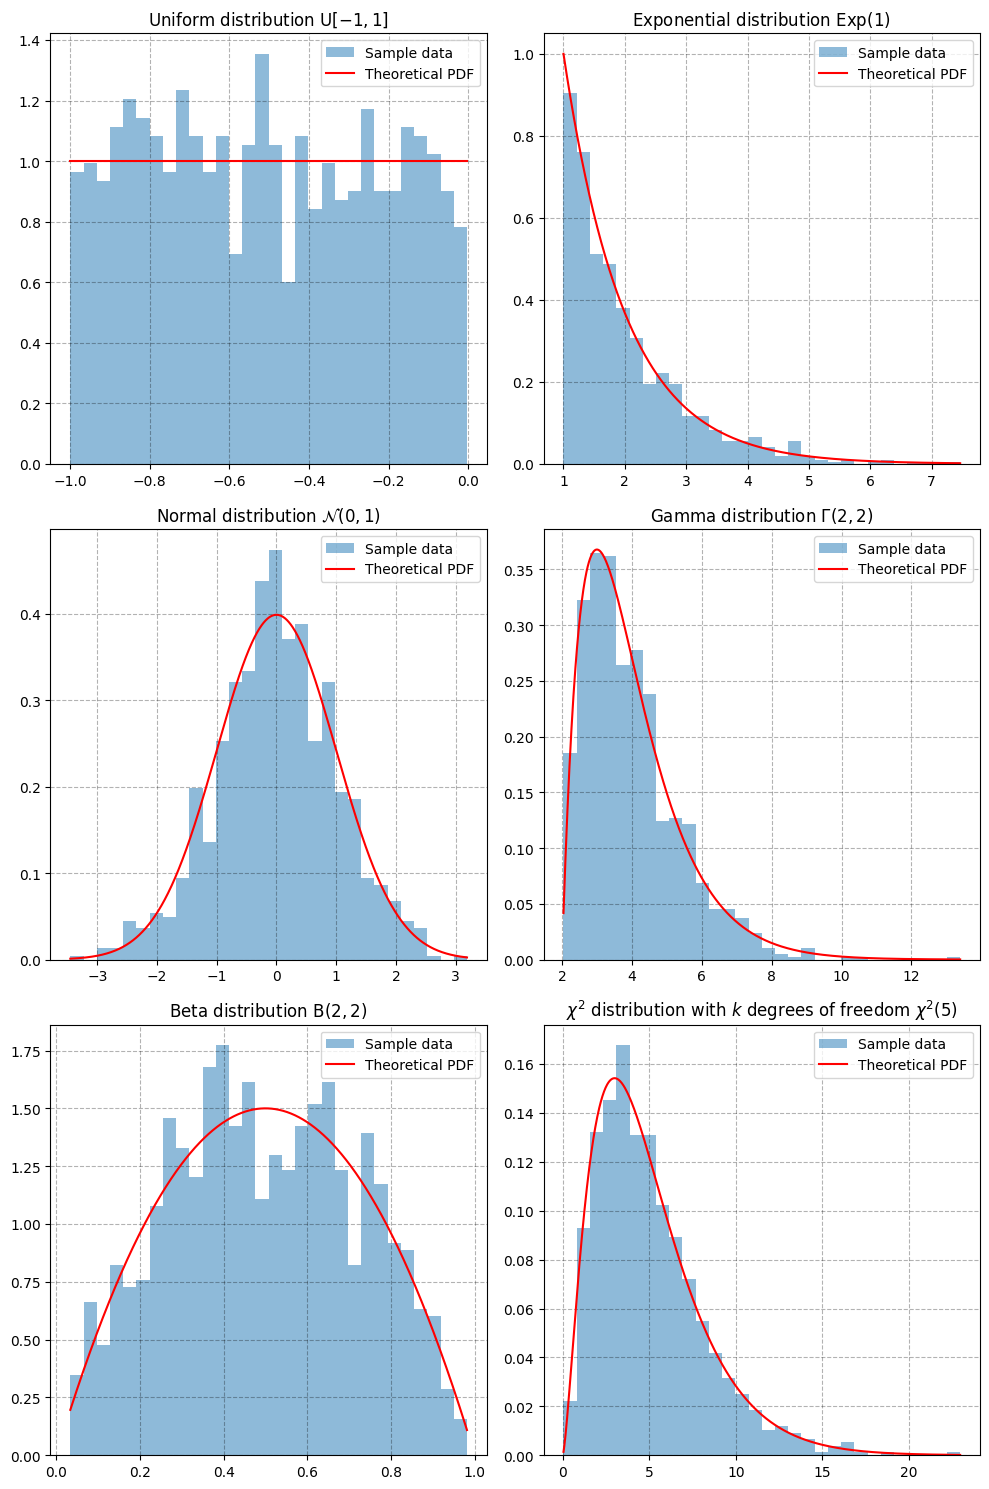

In [ ]:
from scipy import stats
distributions = [
    ("Uniform distribution $\\operatorname{U}[-1, 1]$", stats.uniform, (-1, 1)),
    ("Exponential distribution $\\operatorname{Exp}(1)$", stats.expon, (1,)),
    ("Normal distribution $\\mathcal{N}(0, 1)$", stats.norm, (0, 1)),
    ("Gamma distribution $\\Gamma(2, 2)$", stats.gamma, (2, 2)),
    ("Beta distribution $\\operatorname{B}(2, 2)$", stats.beta, (2, 2)),
    ("$\\chi^2$ distribution with $k$ degrees of freedom $\\chi^2(5)$", stats.chi2, (5,))
]


fig, axs = plt.subplots(3, 2, figsize=(10, 15))
axs = axs.flatten()

for ax, (name, dist, params) in zip(axs, distributions):

    data = dist.rvs(*params, size=1000)

    x = np.linspace(min(data), max(data), 1000)
    pdf = dist.pdf(x, *params)


    ax.hist(data, bins=30, density=True, alpha=0.5, label='Sample data')

    ax.plot(x, pdf, 'r-', label='Theoretical PDF')
    ax.set_title(name)
    ax.legend()
    ax.grid(linestyle='--', color='black', alpha=0.3)

plt.tight_layout()
plt.show()
